In [15]:
import seaborn as sns

# Load Titanic dataset
titanic = sns.load_dataset("titanic")

# Inspect first 5 rows
print(titanic.head())
print(titanic.describe())
print(titanic.info())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.3815

In [27]:
titanic.skew(numeric_only=True)

survived      0.478523
pclass       -0.630548
age           0.389108
sibsp         3.695352
parch         2.749117
fare          4.787317
adult_male   -0.420431
alone        -0.420431
dtype: float64

In [31]:
print(titanic.isnull().sum().to_string())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0


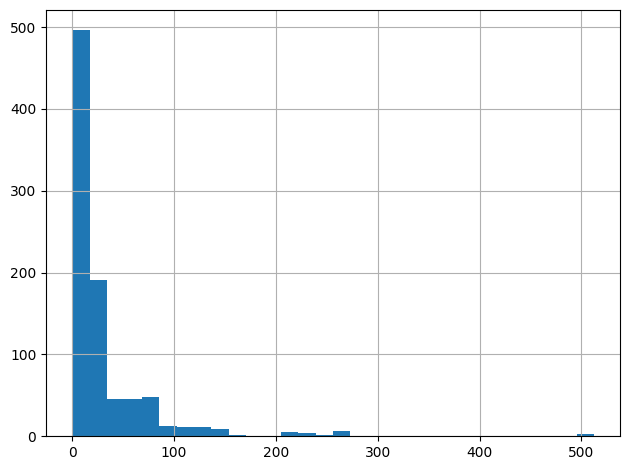

In [29]:
import matplotlib.pyplot as plt

titanic["fare"].hist(bins=30)
plt.show()


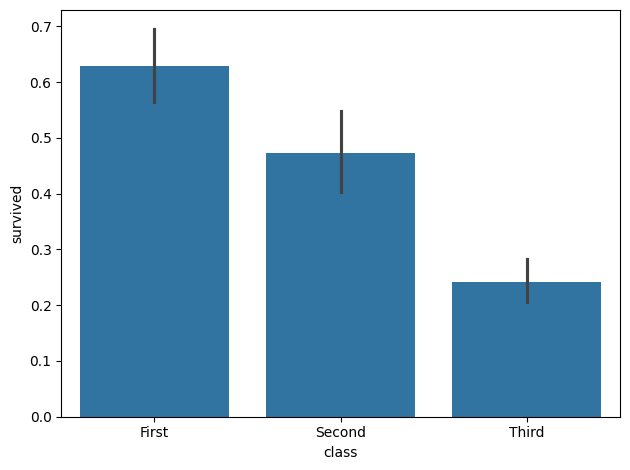

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=titanic, x="class", y="survived")

plt.tight_layout()
plt.show()


In [24]:
import matplotlib.pyplot as plt

plt.rcParams["figure.autolayout"] = True


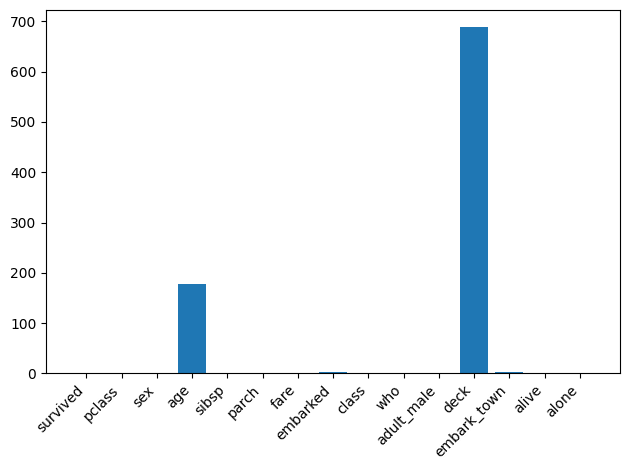

In [26]:
# fig, ax = plt.subplots(constrained_layout=True)
plt.bar(titanic.isnull().sum().index, titanic.isnull().sum().values)
plt.xticks(rotation=45, ha="right")
plt.show()
# plt.tight_layout()

In [7]:
numeric_cols = titanic.select_dtypes(include='number')
corr_matrix = numeric_cols.corr()
corr_matrix

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [ ]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator


class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

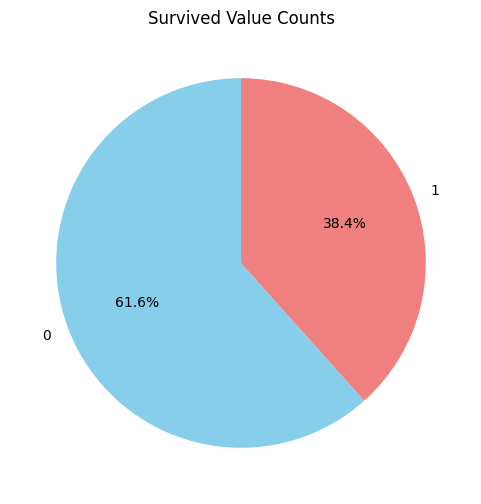

In [7]:
import matplotlib.pyplot as plt

# Count the values in the label column
value_counts = titanic['survived'].value_counts()

# Create pie chart
plt.figure(figsize=(6,6))
plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title("Survived Value Counts")

# Save the chart to a file
plt.savefig("survived_pie_chart.png")

# Optional: Show the chart
plt.show()


In [6]:

from pydantic_core.core_schema import general_after_validator_function
from analyst.nodes import analyst_call
from preprocessor.nodes import preprocessor_call
from state import should_continue, MessagesState, make_tool_node, ask_user_node, should_continue_with_user
from langgraph.graph import StateGraph, START, END
from analyst.tools import tools_by_name as analyst_tools
from preprocessor.tools import tools_by_name as preprocessor_tools
from langgraph.checkpoint.memory import InMemorySaver
import uuid



# Build workflow
agent_builder = StateGraph(MessagesState)
analyst_tool_node = make_tool_node(analyst_tools)
preprocessor_tool_node = make_tool_node(preprocessor_tools)

# Add nodes
agent_builder.add_node("analyst", analyst_call)
agent_builder.add_node("analyst_tools", analyst_tool_node)
agent_builder.add_node("preprocessor", preprocessor_call)
agent_builder.add_node("preprocessor_tools", preprocessor_tool_node)
agent_builder.add_node("user_input",ask_user_node)


# Add edges to connect nodes
agent_builder.add_edge(START, "analyst")
agent_builder.add_conditional_edges(
    "analyst",
    should_continue,
    ["analyst_tools", "preprocessor"]
)
agent_builder.add_edge("analyst_tools", "analyst")


agent_builder.add_conditional_edges(
    "preprocessor",
    should_continue_with_user,
    ["preprocessor_tools","user_input", END]
)
agent_builder.add_edge("preprocessor_tools", "preprocessor")
agent_builder.add_edge("user_input", "preprocessor")

# Compile the agent
checkpointer = InMemorySaver()
agent = agent_builder.compile(checkpointer=checkpointer)

config = {
    "configurable": {
        "thread_id": uuid.uuid4(),
    }
}
print(config)
from langchain.messages import HumanMessage, SystemMessage
messages = [SystemMessage(content="dataset address: \"datasets/Titanic-Dataset.csv\""),HumanMessage(content="Analyze the data")]
gen=agent.stream({"messages":messages},config)
first_chunk=next(gen)
print(first_chunk)
print(messages)
# Show the agent
# from IPython.display import Image, display
# display(Image(agent.get_graph(xray=True).draw_mermaid_png()))



{'configurable': {'thread_id': UUID('439c9569-b5ea-4a0a-a6ca-d1ce66f0c2f1')}}
{'analyst': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'analyse_data', 'arguments': '{"data": "datasets/Titanic-Dataset.csv"}'}, '__gemini_function_call_thought_signatures__': {'241a2629-ec1b-4db0-acff-ec82359cff49': 'CvsBAb4+9vvV0ilHr/Z9/SH801Mp+2JFQZ7UVKPKJkwqimbTXvwA/NRZ0is9lzeb+qiANj7r0MxCMqi82y487s8iqKL8K4/9OPBgGSCqXZ4Gkb6eTR1wyaleIGNqnkt96xKDSnjGtx5/2/SbqXrmYmq53lLzhoOsaVZ0m5kI6dqkpS8i60boIWiPWuU/srx7Jhn5b0ocOcfvKVdzekSWzlUCBjSzQvBVTRtDQ/gE97SfHyzWPiA9ns7Urj7GCG4ydBoHWg6+kaktW0uOWtGPjweY1beAUW6iXMCq7LyOJ/fedEoDggel0fh/OEOn/+reVJ/Y22DvxZ8hNOoR92Y='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c4373-c78b-79f2-a484-5d232cc71737-0', tool_calls=[{'name': 'analyse_data', 'args': {'data': 'datasets/Titanic-Dataset.csv'}, 'id': '241a2629-ec1b-4db0-acff-ec82359cff49', 

In [2]:
# Invoke
from langchain.messages import HumanMessage, SystemMessage
messages = [SystemMessage(content="dataset address: \"datasets/Titanic-Dataset.csv\""),HumanMessage(content="Analyze the data")]
messages = agent.invoke({"messages": messages})
# for m in messages["messages"]:
#     m.pretty_print()

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [3]:
messages

{'messages': [SystemMessage(content='dataset address: "datasets/Titanic-Dataset.csv"', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Analyze the data', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'analyse_data', 'arguments': '{"data": "datasets/Titanic-Dataset.csv"}'}, '__gemini_function_call_thought_signatures__': {'6145755d-6be9-4844-9783-99197cc23de8': 'CqcCAb4+9vvQyEUAzGTM8VKkZM+LEfPQ2mC9FuGxrexv8mfpIj+EJ0zE0okoJiicDwbC1FLBsuHlSPBwbWNi/crXjFDj/seT8al1g6ZgKagg4P6fFqiI42yn62sXt5zZk9u8rMrrTIlgbeF3YDmOOM86ijjsrQh3spY34+r3ZpL0af05R60Nhwu2e3Sk0uLSJMRMr8kklctBc0UsHlIC1P3uSpzgokL+f8TI4vKrXy/Xv0U0h2f4zOfveDioL8SJRuZhJsAhaLCiP67D9Qkj7l9c28NiQ6F5Es2GwvGC4Ak/7Y9OXcYwjZO8UAmo2ssK3jF6gdcIl0aNrk+b9cWg7sKOVXXY+fxDQRMe6mnQqDSZgv3aa7N8vmv/T+R6LbAqvo0Y0SvA4xKMjw=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_r

In [8]:
input("Enter")

'sup'

In [7]:
for message in messages['messages'][-2:]:
    print(message.content[0]['text'])

---

### **Description of the Data**
The Titanic dataset contains **891 rows** and **12 columns**. It is a classic dataset used for binary classification tasks, where the goal is to predict survival.

- **Label Column:** `Survived` (Binary: 0 = No, 1 = Yes)
- **Data Types:**
    - **Numeric:** `PassengerId`, `Survived`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`
    - **Categorical/Text:** `Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`

---

### **Data Imbalance**
The dataset shows a moderate imbalance between the target classes. Approximately **38.4%** of the passengers survived, while **61.6%** did not. While there is a difference, it is not extreme enough to severely hinder standard machine learning models, though techniques like stratified sampling might still be beneficial.

![Label Pie Chart](images/label_pie_chart.png)

---

### **Null Values**
Several columns contain missing information that will require preprocessing:

- **Cabin:** This column has a significantly high number of n

In [13]:
report = messages['messages'][-1].content[0]['text']

In [14]:
with open("report.md","w", encoding="utf-8") as f:
    f.write(report)